# Grid plots
This is after cleaning up by visual inspection "spiky" models

In [1]:
import numpy as np
import glob
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from MESAreader import get_src_col, get_model_initial_values, Rsun_cm
import matplotlib.colors as mcolors
from joblib import Parallel, delayed
%load_ext autoreload
%autoreload 2

Hardcoded some constants


In [2]:
root = "../data/" # final / needed
hfiles = sorted(glob.glob(root+"*/LOGS/history.data"))
models = sorted(glob.glob(root+"*.*/"))
print(f"Number of successful models in the grid: {len(hfiles)}")

Number of successful models in the grid: 113


/tmp/ipykernel_59117/754912429.py:22: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  plt.savefig('../manuscript/figures/HRD_grid.pdf')
/tmp/ipykernel_59117/754912429.py:22: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  plt.savefig('../manuscript/figures/HRD_grid.pdf')
/home/mrenzo/Documents/Research/codes/miniforge3/envs/CHE_jet/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  fig.canvas.print_figure(bytes_io, **kw)


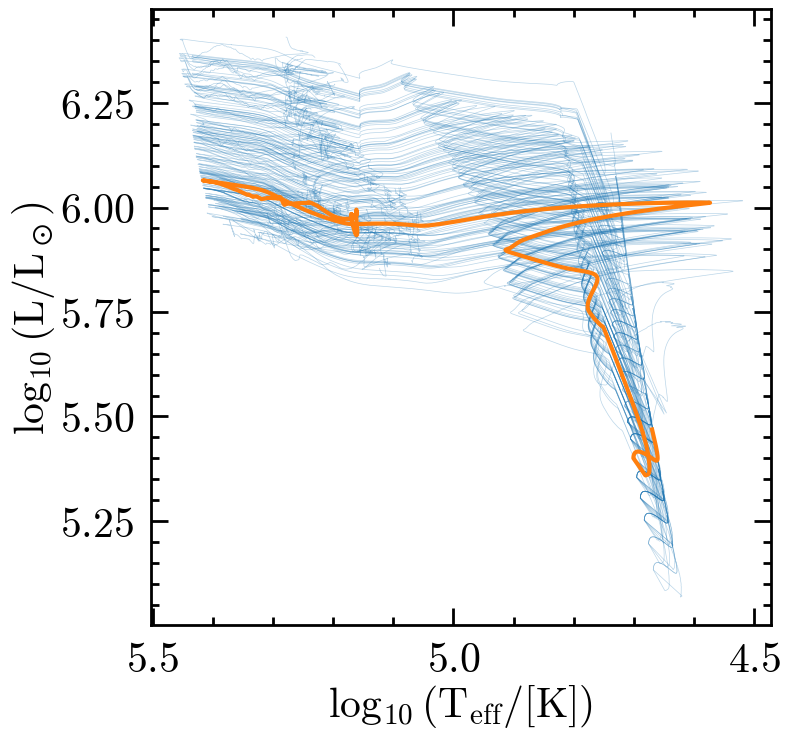

In [9]:
fig = plt.figure()
gs = gridspec.GridSpec(150, 100)
ax = fig.add_subplot(gs[:, :])

ax.invert_xaxis()
ax.set_xlabel(r"$\log_{10}(T_\mathrm{eff}/[K])$")
ax.set_ylabel(r"$\log_{10}(L/L_\odot)$")

models = sorted(glob.glob(root+"*.*rot*/"))
for m in models:
    # print(m)
    hfile = m+"/LOGS/history.data"
    M, o = get_model_initial_values(m)
    # print(M, o)
    src, col = get_src_col(hfile)
    logT = src[:, col.index("log_Teff")]
    logL = src[:, col.index("log_L")]
    ax.plot(logT, logL, lw=0.5, alpha=0.3, c='C0')
    if M==40 and o==0.6:
        ax.plot(logT, logL, lw=3, c='C1',zorder=10)

plt.savefig('../manuscript/figures/HRD_grid.pdf')

# density profiles

In [10]:
def my_mark_inset(parent_axes, inset_axes, loc1a=1, loc1b=1, loc2a=2, loc2b=2, **kwargs):
    from mpl_toolkits.axes_grid1.inset_locator import TransformedBbox, BboxPatch, BboxConnector
    rect = TransformedBbox(inset_axes.viewLim, parent_axes.transData)

    pp = BboxPatch(rect, fill=False, **kwargs)
    parent_axes.add_patch(pp)

    p1 = BboxConnector(inset_axes.bbox, rect, loc1=loc1a, loc2=loc1b, **kwargs)
    inset_axes.add_patch(p1)
    p1.set_clip_on(False)
    p2 = BboxConnector(inset_axes.bbox, rect, loc1=loc2a, loc2=loc2b, **kwargs)
    inset_axes.add_patch(p2)
    p2.set_clip_on(False)

    return pp, p1, p2


/tmp/ipykernel_59117/1220717418.py:32: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  plt.savefig('/home/mrenzo/Documents/Research/Projects/CHE_jets/progenitors_grid_manuscript/figures/rho_grid.pdf')
/tmp/ipykernel_59117/1220717418.py:32: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  plt.savefig('/home/mrenzo/Documents/Research/Projects/CHE_jets/progenitors_grid_manuscript/figures/rho_grid.pdf')


/home/mrenzo/Documents/Research/codes/miniforge3/envs/CHE_jet/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  fig.canvas.print_figure(bytes_io, **kw)


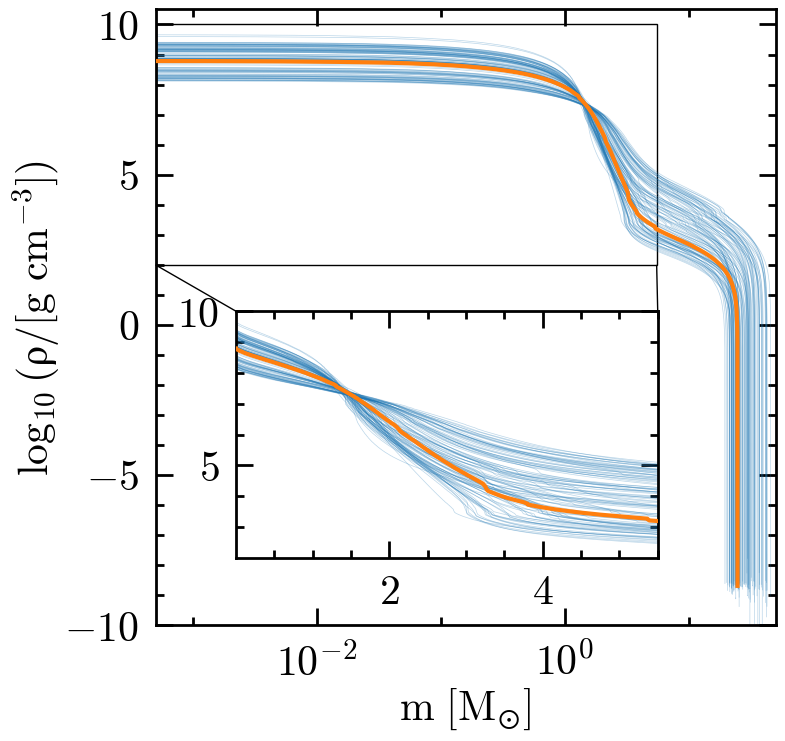

In [11]:
fig = plt.figure()
gs = gridspec.GridSpec(150, 100)
ax = fig.add_subplot(gs[:, :])
# zx = ax.inset_axes([0.3, 0.76, 0.68, 0.2])  # for x=mass
zx = ax.inset_axes([0.13, 0.11, 0.68, 0.4])  # for x=logM


for mod in models:
    pfile = mod+"LOGS/CHE_single_core_collapse.data"
    src, col = get_src_col(pfile)
    logrho = src[:, col.index("logRho")]
    m = src[:, col.index("mass")]
    ax.plot(m, logrho, c='C0', alpha=0.3, lw=0.5)
    zx.plot(m, logrho, c='C0', alpha=0.3, lw=0.5)
    M, o = get_model_initial_values(mod)
    if M==40 and o==0.6:
        ax.plot(m, logrho, lw=3, c='C1', zorder=10)
        zx.plot(m, logrho, lw=3, c='C1', zorder=10)
    


ax.set_ylim(-10, 10.5)
ax.set_xscale('log')
ax.set_xlim(5e-4, 50)
zx.set_xlim(5e-4, 5.5)
zx.set_ylim(2,10)
ax.set_xlabel(r"$m\ [M_{\odot}]$")
ax.set_ylabel(r"$\log_{10}(\rho/\mathrm{[g\ cm^{-3}}])$")
my_mark_inset(ax, zx, loc1a=2, loc1b=3, loc2a=1, loc2b=4)
ax.set_xticks([1e-3, 1e-1, 1e1], minor=True)
ax.set_xticklabels([], minor=True)
plt.savefig('/home/mrenzo/Documents/Research/Projects/CHE_jets/progenitors_grid_manuscript/figures/rho_grid.pdf')

# am profiles

/tmp/ipykernel_59117/129753494.py:30: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  plt.savefig('/home/mrenzo/Documents/Research/Projects/CHE_jets/progenitors_grid_manuscript/figures/j_grid.pdf')
/tmp/ipykernel_59117/129753494.py:30: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  plt.savefig('/home/mrenzo/Documents/Research/Projects/CHE_jets/progenitors_grid_manuscript/figures/j_grid.pdf')
/home/mrenzo/Documents/Research/codes/miniforge3/envs/CHE_jet/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  fig.canvas.print_figure(bytes_io, **kw)


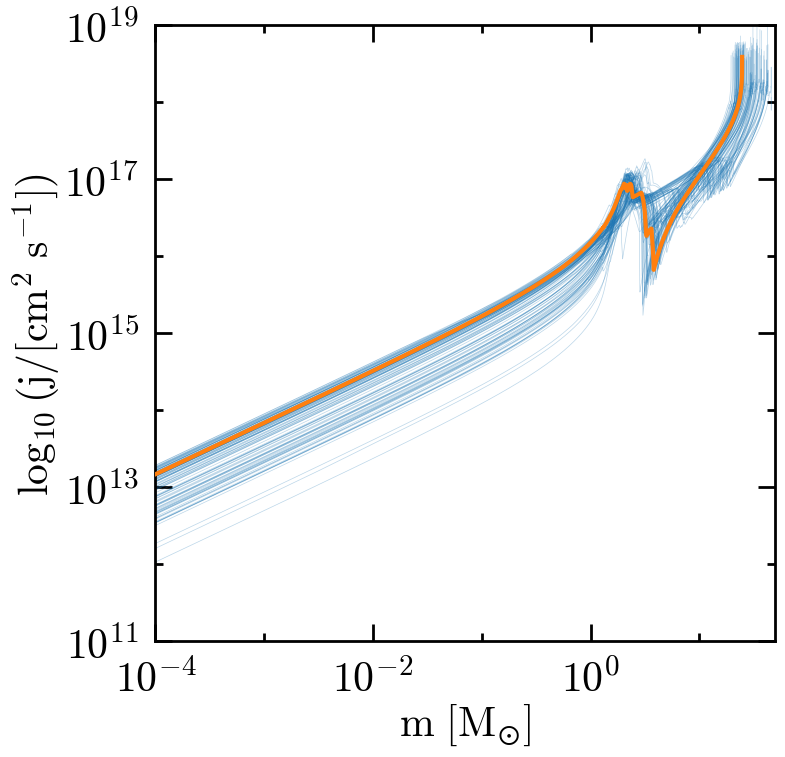

In [12]:
fig = plt.figure()
gs = gridspec.GridSpec(150, 100)
ax = fig.add_subplot(gs[:, :])

for mod in models:
    pfile = mod+"LOGS/CHE_single_core_collapse.data"
    src, col = get_src_col(pfile)
    logr = np.log10((10.**(src[:, col.index("logR")]))*Rsun_cm)
    r = 10.0**logr
    omega = src[:, col.index("omega")]
    j_specific = r*r*omega
    m = src[:, col.index("mass")]
    ax.plot(m, j_specific, c='C0', alpha=0.3, lw=0.5)
    M, o = get_model_initial_values(mod)
    if M==40 and o==0.6:
        ax.plot(m, j_specific, lw=3, c='C1', zorder=10)

ax.set_yscale('log')
ax.set_ylim(1e11, 1e19)

ax.set_xscale('log')
ax.set_xlim(1e-4, 50)
ax.set_xticks([1e-3, 1e-1, 1e1], minor=True)
ax.set_xticklabels([], minor=True)
ax.set_yticks([1e12, 1e14, 1e16, 1e18], minor=True)
ax.set_yticklabels([], minor=True)
ax.set_xlabel(r"$m \ [M_{\odot}]$")
# ax.set_xlabel(r"m [$M_{\odot}$]")
ax.set_ylabel(r"$\log_{10}(j/\mathrm{[cm^{2}\ s^{-1}]})$")
plt.savefig('/home/mrenzo/Documents/Research/Projects/CHE_jets/progenitors_grid_manuscript/figures/j_grid.pdf')


# B-field profiles

/tmp/ipykernel_59117/1082820061.py:28: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  plt.savefig('/home/mrenzo/Documents/Research/Projects/CHE_jets/progenitors_grid_manuscript/figures/B_phi_grid.pdf')
/tmp/ipykernel_59117/1082820061.py:28: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  plt.savefig('/home/mrenzo/Documents/Research/Projects/CHE_jets/progenitors_grid_manuscript/figures/B_phi_grid.pdf')


/home/mrenzo/Documents/Research/codes/miniforge3/envs/CHE_jet/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  fig.canvas.print_figure(bytes_io, **kw)


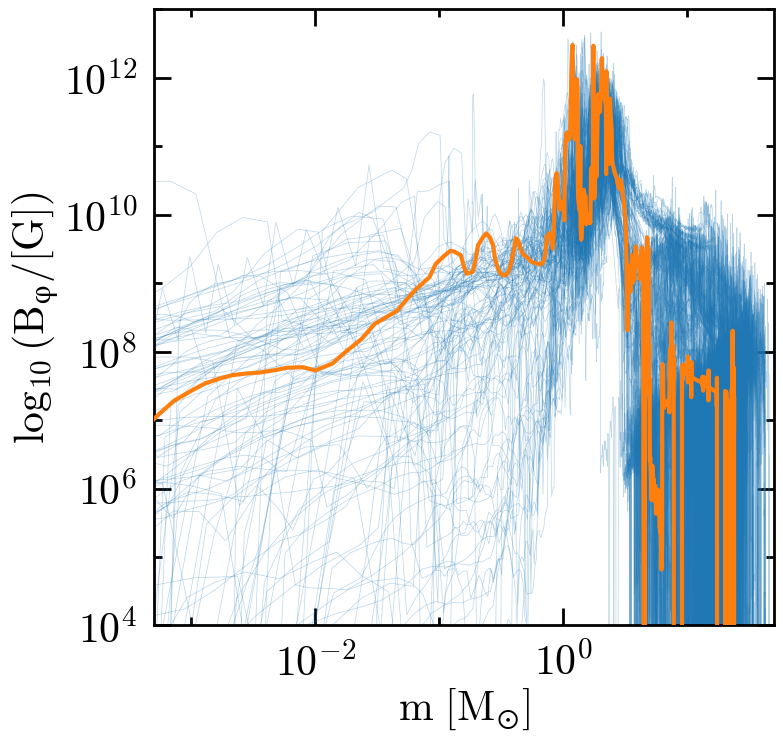

In [13]:
fig = plt.figure()
gs = gridspec.GridSpec(150, 100)
ax = fig.add_subplot(gs[:, :])

for mod in models:
    pfile = mod+"LOGS/CHE_single_core_collapse.data"
    src, col = get_src_col(pfile)
    m = src[:, col.index("mass")]
    Bphi = 10.0**(src[:, col.index("dynamo_log_B_phi")])
    ax.plot(m, Bphi, c='C0', alpha=0.3, lw=0.5)
    M, o = get_model_initial_values(mod)
    if M==40 and o==0.99:
        ax.plot(m, Bphi, lw=3, c='C1', zorder=10)

# ax.set_yscale('log')
# ax.set_ylim(ymin=0, ymax=14)
ax.set_ylim(1e4, 1e13)
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlim(5e-4, 50)
ax.set_xticks([1e-3, 1e-1, 1e1], minor=True)
ax.set_xticklabels([], minor=True)
ax.set_yticks([1e13, 1e11, 1e9, 1e7, 1e5], minor=True)
ax.set_yticklabels([], minor=True)
ax.set_xlabel(r"$m\ [M_{\odot}]$")

ax.set_ylabel(r"$\log_{10}(B_{\varphi}/\mathrm{[G]})$")
plt.savefig('/home/mrenzo/Documents/Research/Projects/CHE_jets/progenitors_grid_manuscript/figures/B_phi_grid.pdf')


# Ye

/tmp/ipykernel_53860/1677778301.py:28: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  plt.savefig('/home/mrenzo/Documents/Research/Projects/CHE_jets/progenitors_grid_manuscript/figures/Ye_grid.pdf')


/tmp/ipykernel_53860/1677778301.py:28: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  plt.savefig('/home/mrenzo/Documents/Research/Projects/CHE_jets/progenitors_grid_manuscript/figures/Ye_grid.pdf')
/home/mrenzo/Documents/Research/codes/miniforge3/envs/CHE_jet/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  fig.canvas.print_figure(bytes_io, **kw)


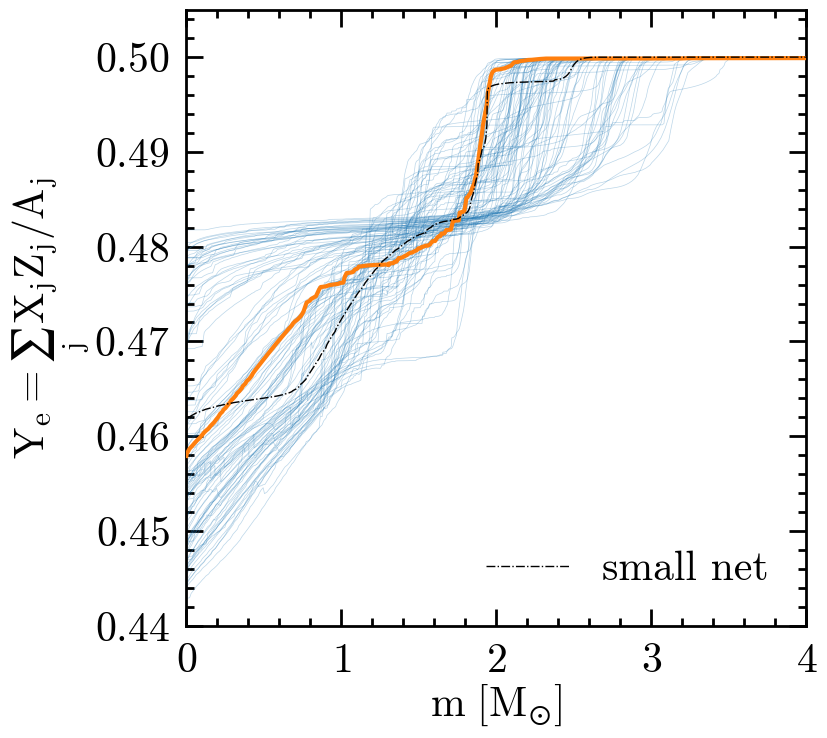

In [32]:
fig = plt.figure()
gs = gridspec.GridSpec(150, 100)
ax = fig.add_subplot(gs[:, :])

for mod in models:
    pfile = mod+"LOGS/CHE_single_core_collapse.data"
    src, col = get_src_col(pfile)
    m = src[:, col.index("mass")]
    ye = src[:, col.index('ye')]
    ax.plot(m, ye, c='C0', alpha=0.3, lw=0.5)

    M, o = get_model_initial_values(mod)
    if M==40 and o==0.6:
        ax.plot(m, ye, lw=3, c='C1', zorder=10)
        # this model is available at https://zenodo.org/records/11375523
        small_net = "/home/mrenzo/Results/CHE_jets_grid/CLEAN/SMALL_NET/40_rot0.6_small_net/LOGS1/CHE_single_core_collapse.data"
        src, col = get_src_col(small_net)
        m = src[:, col.index("mass")]
        ye = src[:, col.index('ye')]
        ax.plot(m, ye, c='k', ls='-.', alpha=1, lw=1, zorder=10, label=r"small net")
        ax.legend()

# ax.set_xscale('log')
ax.set_xlim(0, 4)
ax.set_ylim(0.44, 0.505)
ax.set_ylabel(r"$Y_e=\sum_j\,X_j Z_j / A_j$")
ax.set_xlabel(r"$m\ [M_{\odot}]$")
plt.savefig('/home/mrenzo/Documents/Research/Projects/CHE_jets/progenitors_grid_manuscript/figures/Ye_grid.pdf')

# Entropy profile

/tmp/ipykernel_53860/619261363.py:24: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  plt.savefig('/home/mrenzo/Documents/Research/Projects/CHE_jets/progenitors_grid_manuscript/figures/entropy_grid.pdf')
/tmp/ipykernel_53860/619261363.py:24: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  plt.savefig('/home/mrenzo/Documents/Research/Projects/CHE_jets/progenitors_grid_manuscript/figures/entropy_grid.pdf')
/home/mrenzo/Documents/Research/codes/miniforge3/envs/CHE_jet/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  fig.canvas.print_figure(bytes_io, **kw)


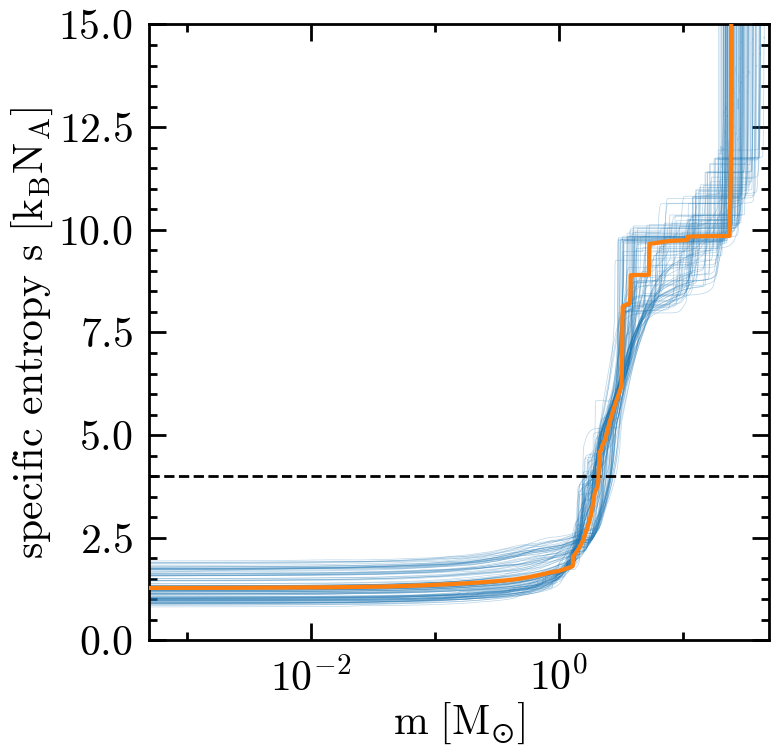

In [33]:
fig = plt.figure()
gs = gridspec.GridSpec(150, 100)
ax = fig.add_subplot(gs[:, :])

for mod in models:
    pfile = mod+"LOGS/CHE_single_core_collapse.data"
    src, col = get_src_col(pfile)
    s = src[:, col.index("entropy")]
    m = src[:, col.index("mass")]
    ax.plot(m, s, c='C0', alpha=0.3, lw=0.5)
    M, o = get_model_initial_values(mod)
    if M==40 and o==0.6:
        ax.plot(m, s, lw=3, c='C1', zorder=10)
    

ax.set_ylim(0, 15)
ax.set_xscale('log')
ax.set_xlim(5e-4, 50)
ax.set_xlabel(r"$m\ [M_{\odot}]$")
ax.set_ylabel(r"specific entropy $s\ [k_{B}N_{A}]$")
ax.set_xticks([1e-3, 1e-1, 1e1], minor=True)
ax.set_xticklabels([], minor=True)
ax.axhline(4, 0,1,lw=2, ls='--', c='k')
plt.savefig('/home/mrenzo/Documents/Research/Projects/CHE_jets/progenitors_grid_manuscript/figures/entropy_grid.pdf')

# Multi-panel single figure

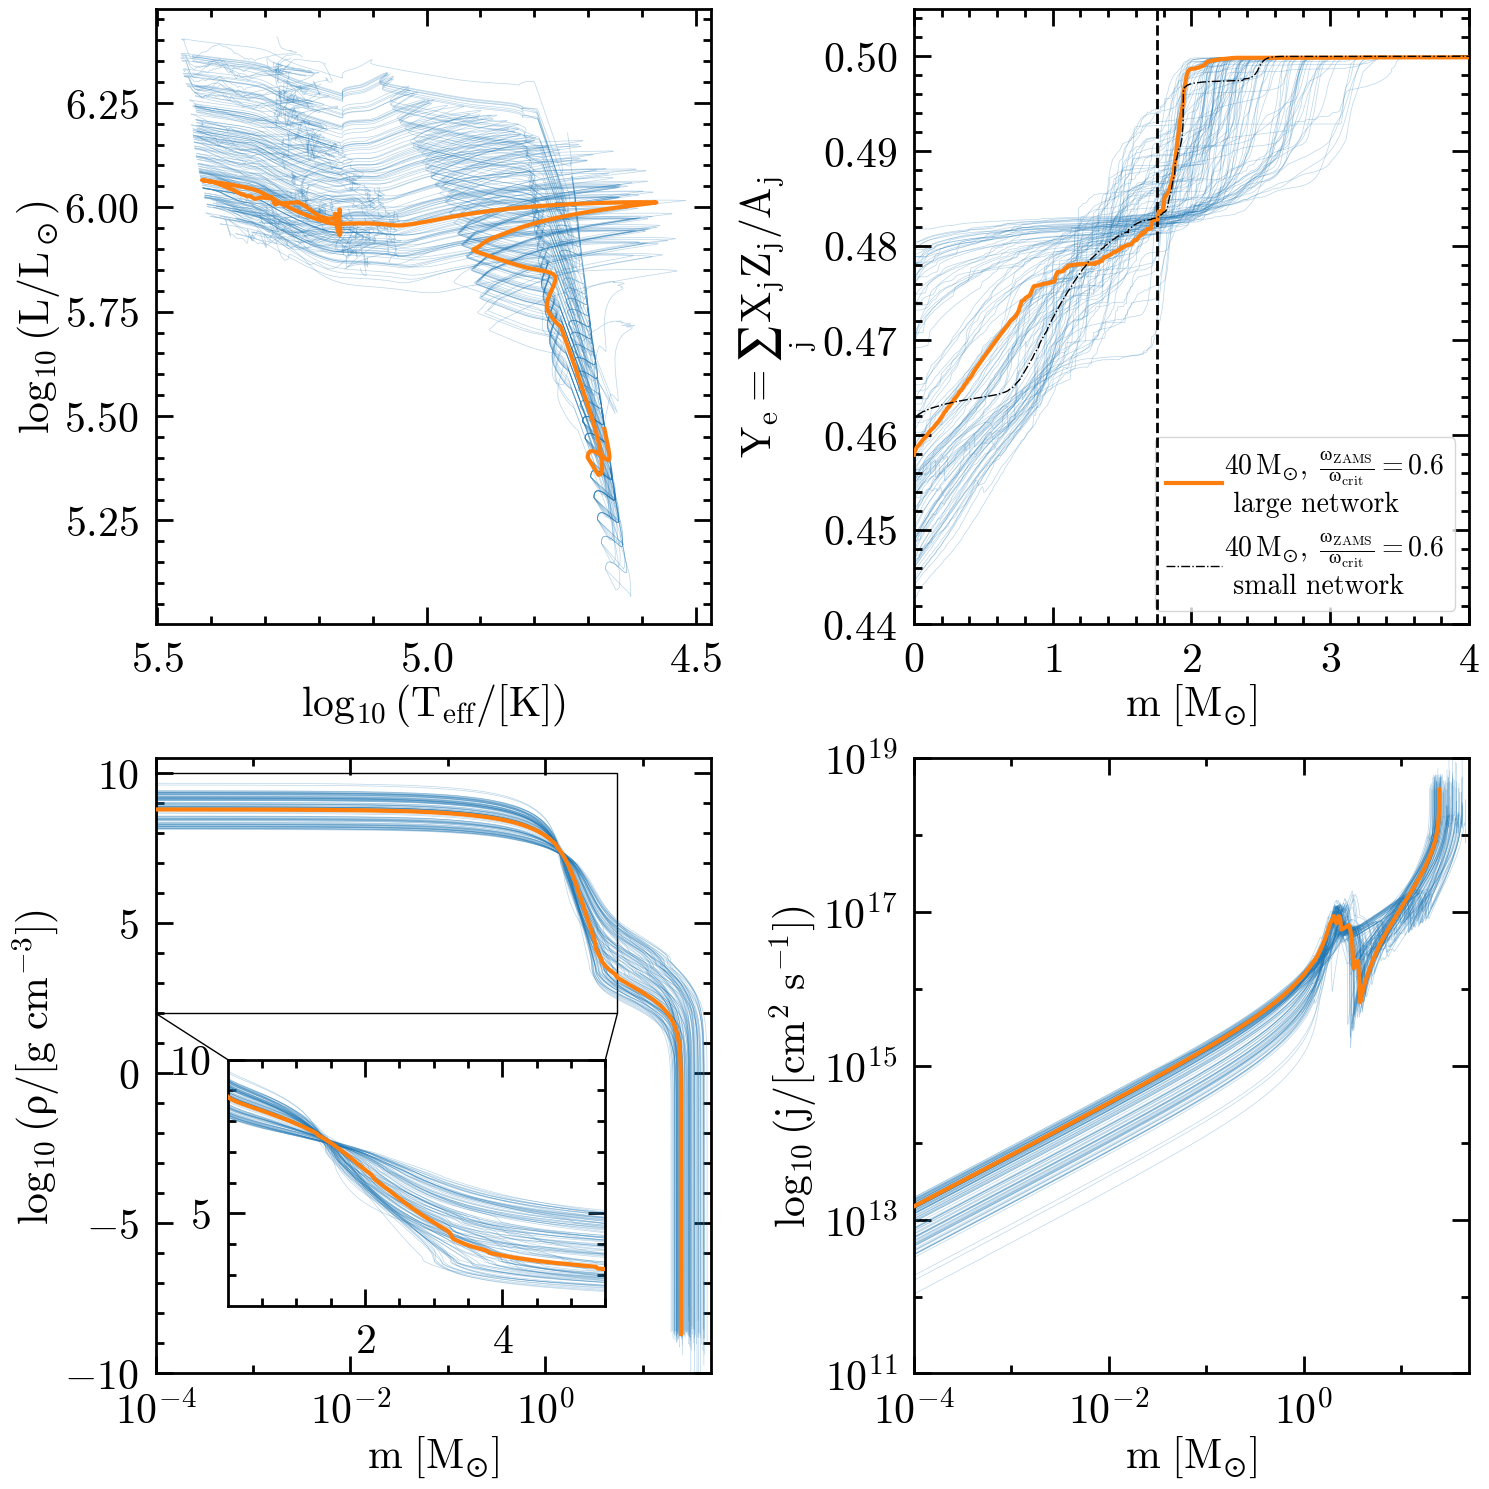

In [63]:
fig = plt.figure(figsize=(15,15))
gs = gridspec.GridSpec(2, 2)
ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1])
ax2 = fig.add_subplot(gs[2])
ax3 = fig.add_subplot(gs[3])
zx = ax2.inset_axes([0.13, 0.11, 0.68, 0.4])  # for x=logM
models = sorted(glob.glob(root+"*.*rot*/"))

# HRD ---------------------------------------
for mod in models:
    hfile = mod+"/LOGS/history.data"
    M, o = get_model_initial_values(mod)
    # print(M, o)
    src, col = get_src_col(hfile)
    logT = src[:, col.index("log_Teff")]
    logL = src[:, col.index("log_L")]
    ax0.plot(logT, logL, lw=0.5, alpha=0.3, c='C0')
    if M==40 and o==0.6:
        ax0.plot(logT, logL, lw=3, c='C1',zorder=10)


    # Ye ----------------------------------------------------
    pfile = mod+"LOGS/CHE_single_core_collapse.data"
    src, col = get_src_col(pfile)
    m = src[:, col.index("mass")]
    ye = src[:, col.index('ye')]
    ax1.plot(m, ye, c='C0', alpha=0.3, lw=0.5, zorder=1)
    if M==40 and o==0.6:
        ax1.plot(m, ye, lw=3, c='C1', zorder=10, label=r"$40\,M_{\odot},\ \frac{\omega_{\rm ZAMS}}{\omega_{\rm crit}}=0.6$"+"\n large network")
        ax1.axvline(1.75, 0,1,ls='--', lw=2, zorder=9, c='k')
        try:
            # this model is available at https://zenodo.org/records/11375523
            small_net = "/home/mrenzo/Results/CHE_jets_grid/CLEAN/SMALL_NET/40_rot0.6_small_net/LOGS1/CHE_single_core_collapse.data"
            src, col = get_src_col(small_net)
            m = src[:, col.index("mass")]
            ye = src[:, col.index('ye')]
            ax1.plot(m, ye, c='k', ls='-.', lw=1,
                     zorder=10,
                     label=r"$40\,M_{\odot},\ \frac{\omega_{\rm ZAMS}}{\omega_{\rm crit}}=0.6$"+"\n small network")
            ax1.legend(fontsize=20, handletextpad=0.1, frameon=True)
        except:
            print("No small net?")
            pass
       
    # density -----------------------------
    pfile = mod+"LOGS/CHE_single_core_collapse.data"
    src, col = get_src_col(pfile)
    logrho = src[:, col.index("logRho")]
    m = src[:, col.index("mass")]
    ax2.plot(m, logrho, c='C0', alpha=0.3, lw=0.5)
    zx.plot(m, logrho, c='C0', alpha=0.3, lw=0.5)
    if M==40 and o==0.6:
        ax2.plot(m, logrho, lw=3, c='C1', zorder=10)
        zx.plot(m, logrho, lw=3, c='C1', zorder=10)
    
    # AM profile --------------------------------------------------
    pfile = mod+"LOGS/CHE_single_core_collapse.data"
    src, col = get_src_col(pfile)
    logr = np.log10((10.**(src[:, col.index("logR")]))*Rsun_cm)
    r = 10.0**logr
    omega = src[:, col.index("omega")]
    j_specific = r*r*omega
    m = src[:, col.index("mass")]
    ax3.plot(m, j_specific, c='C0', alpha=0.3, lw=0.5)
    if M==40 and o==0.6:
        ax3.plot(m, j_specific, lw=3, c='C1', zorder=10)



ax0.invert_xaxis()
ax0.set_xlabel(r"$\log_{10}(T_\mathrm{eff}/[K])$")
ax0.set_ylabel(r"$\log_{10}(L/L_\odot)$")

# ax1.set_xscale('log')
ax1.set_xlim(0, 4)
ax1.set_ylim(0.44, 0.505)
ax1.set_ylabel(r"$Y_e=\sum_j\,X_j Z_j / A_j$")
ax1.set_xlabel(r"$m\ [M_{\odot}]$")

ax2.set_ylim(-10, 10.5)
ax2.set_xscale('log')
ax2.set_xlim(1e-4, 50)
zx.set_xlim(1e-4, 5.5)
zx.set_ylim(2,10)
ax2.set_xlabel(r"$m\ [M_{\odot}]$")
ax2.set_ylabel(r"$\log_{10}(\rho/\mathrm{[g\ cm^{-3}}])$")
my_mark_inset(ax2, zx, loc1a=2, loc1b=3, loc2a=1, loc2b=4)
ax2.set_xticks([1e-3, 1e-1, 1e1], minor=True)
ax2.set_xticklabels([], minor=True)
       
ax3.set_yscale('log')
ax3.set_ylim(1e11, 1e19)

ax3.set_xscale('log')
ax3.set_xlim(1e-4, 50)
ax3.set_xticks([1e-3, 1e-1, 1e1], minor=True)
ax3.set_xticklabels([], minor=True)
ax3.set_yticks([1e12, 1e14, 1e16, 1e18], minor=True)
ax3.set_yticklabels([], minor=True)
ax3.set_xlabel(r"$m\ [M_{\odot}]$")
# ax3.set_xlabel(r"m [$M_{\odot}$]")
ax3.set_ylabel(r"$\log_{10}(j/\mathrm{[cm^{2}\ s^{-1}]})$")

fig.align_ylabels()
plt.savefig('/home/mrenzo/Documents/Research/Projects/CHE_jets/progenitors_grid_manuscript/figures/multipanel_grid.pdf')


# Compactness vs. Mzams and omega

[1.4145477156856707, 3.13805226000115, 2.2349501177145283, 1.7566536118893574, 2.20586579330705, 2.095278727428803, 1.3253831833677154, 1.451269719653352, 1.761915145520431, 1.460325752692847, 2.1070797665135594, 2.1034719090097056, 3.3902557485445675, 2.113589350756517, 1.4946522043557848, 2.203006055692534, 1.31184956348351, 1.4196485492506772, 2.1263298329467926, 2.1210837520447767, 2.1754379140111744, 2.364180033314159, 2.4481091892359568, 1.6616399814903011, 1.4061038464581297, 1.5393514095229186, 1.4236554543408122, 2.1606397165474824, 1.4833400006557766, 1.6208172820322697, 2.7592596282038713, 2.2270638974929233, 2.1765056527562474, 2.1618274526747188, 2.6769768400867884, 1.4940458276976023, 1.3719991978898203, 1.7200692538982716, 1.5870381880510942, 2.06918274315663, 1.80864536159081, 1.8910276652249298, 2.162217749380259, 1.584690504384004, 2.316155155567363, 2.0833950420349896, 2.1821656635277313, 2.1677152547372334, 2.4094052370096573, 1.366682994234443, 2.209754995940231, 2

/tmp/ipykernel_53860/1257754226.py:43: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  plt.savefig('/home/mrenzo/Documents/Research/Projects/CHE_jets/progenitors_grid_manuscript/figures/xi_M.pdf')


/tmp/ipykernel_53860/1257754226.py:43: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  plt.savefig('/home/mrenzo/Documents/Research/Projects/CHE_jets/progenitors_grid_manuscript/figures/xi_M.pdf')
/home/mrenzo/Documents/Research/codes/miniforge3/envs/CHE_jet/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  fig.canvas.print_figure(bytes_io, **kw)


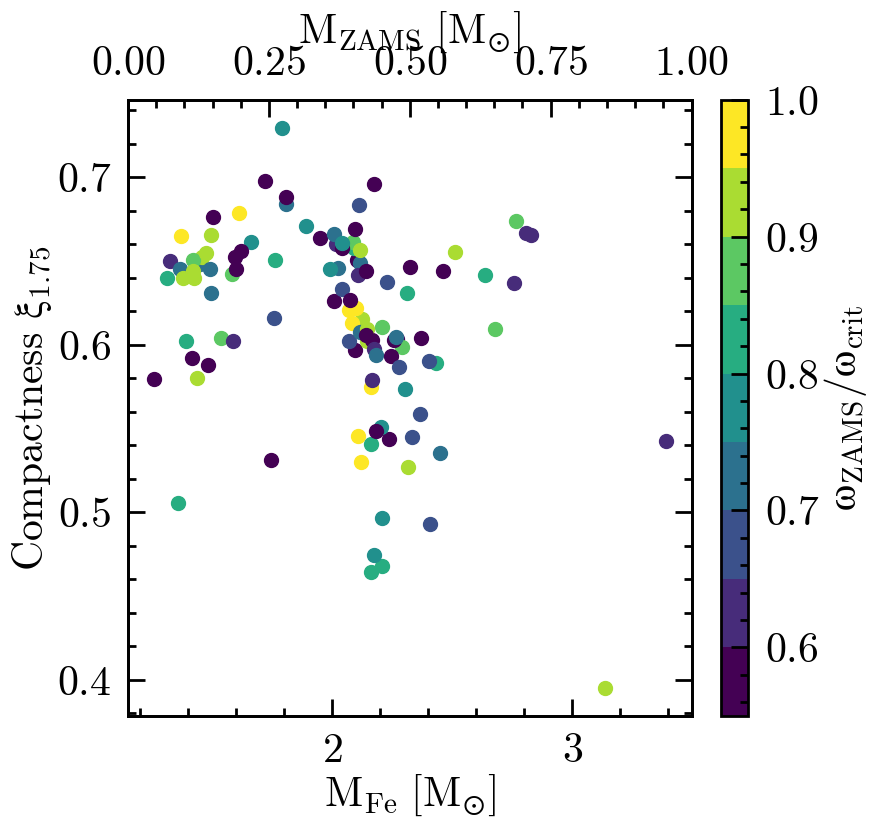

In [67]:
fig = plt.figure()
gs = gridspec.GridSpec(150, 110)
ax = fig.add_subplot(gs[:, :100])
tax=ax.twiny()
cax = fig.add_subplot(gs[:, 105:])

n_colors = 9
vmin, vmax = 0.55, 1.0

base_cmap = plt.cm.viridis
bounds = np.linspace(vmin, vmax, n_colors + 1)
norm = mcolors.BoundaryNorm(bounds, base_cmap.N)

cmap_discrete = mcolors.ListedColormap(
    [base_cmap(norm(v)) for v in (bounds[:-1] + bounds[1:]) / 2]
)

mfes = []
mzams = []

for mod in models:
    pfile = mod+"LOGS/CHE_single_core_collapse.data"
    hfile = mod+"LOGS/history.data"
    src, col = get_src_col(hfile)
    Mfe = src[-1, col.index("fe_core_mass")]
    mfes.append(Mfe)
    mzams.append(mzams)
    M, o = get_model_initial_values(mod)
    xi, M4, mu4 = compute_profile_quantities(pfile, M_compact=1.75, s_thresh=4.0)
    p = ax.scatter(Mfe, xi, c=o, s=100, cmap=cmap_discrete,
                   norm=mcolors.Normalize(vmin, vmax))

print(mfes, mzams)
# create top axis


plt.colorbar(p, cax=cax)
tax.set_xlabel(r"$M_{\rm ZAMS} \ [M_{\odot}]$")
ax.set_xlabel(r"$M_{\rm Fe} \ [M_{\odot}]$")
ax.set_ylabel(r"Compactness $\xi_{1.75}$")
cax.set_ylabel(r"$\omega_{\rm ZAMS}/\omega_{\rm crit}$")

plt.savefig('/home/mrenzo/Documents/Research/Projects/CHE_jets/progenitors_grid_manuscript/figures/xi_M.pdf')

# Build appendix table
The table is written in latex, the content is copy pasted manually from here into `../manuscript/table.tex`

In [69]:
Mprev = -99
for mod in models:
    pfile = mod+"LOGS/CHE_single_core_collapse.data"
    hfile = mod+"LOGS/history.data"
    src, col = get_src_col(hfile)
    Mfe = src[-1, col.index("fe_core_mass")]
    he4 = src[-1, col.index("surface_he4")]
    c12 = src[-1, col.index("surface_c12")]
    o16 = src[-1, col.index("surface_o16")]
    xi, M4, mu4 = compute_profile_quantities(pfile, M_compact=1.75, s_thresh=4.0)
    M, o = get_model_initial_values(mod)
    if M != Mprev:
        print("\hline")
        Mprev = M
    print(f"{M:.2f} & {o:.2f} & {xi:.3f} & {Mfe:.2f} & {M4:.2f} & {mu4:.3f} & {he4:.2f} & {c12:.2f} & {o16:.2f}"+r"\\")


\hline
30.00 & 0.55 & 0.592 & 1.41 & 1.70 & 0.173 & 0.34 & 0.32 & 0.16 & 0.48\\
30.00 & 0.94 & 0.395 & 3.14 & 1.56 & 0.114 & 0.81 & 0.26 & 0.16 & 0.51\\
\hline
32.00 & 0.55 & 0.544 & 2.23 & 1.96 & 0.134 & 0.17 & 0.31 & 0.21 & 0.42\\
32.00 & 0.70 & 0.616 & 1.76 & 1.81 & 0.133 & 0.48 & 0.31 & 0.15 & 0.46\\
32.00 & 0.84 & 0.468 & 2.21 & 1.58 & 0.143 & 1.18 & 0.46 & 0.09 & 0.34\\
\hline
34.00 & 0.60 & 0.597 & 2.10 & 1.88 & 0.133 & 1.12 & 0.66 & 0.04 & 0.22\\
34.00 & 0.65 & 0.650 & 1.33 & 1.95 & 0.179 & 0.55 & 0.37 & 0.14 & 0.44\\
34.00 & 0.74 & 0.648 & 1.45 & 2.05 & 0.166 & 0.27 & 0.24 & 0.17 & 0.54\\
34.00 & 0.84 & 0.651 & 1.76 & 1.90 & 0.132 & 0.28 & 0.26 & 0.16 & 0.53\\
34.00 & 0.94 & 0.652 & 1.46 & 1.91 & 0.153 & 0.42 & 0.40 & 0.14 & 0.41\\
34.00 & 0.99 & 0.545 & 2.11 & 1.85 & 0.127 & 1.00 & 0.73 & 0.04 & 0.17\\
\hline
36.00 & 0.60 & 0.651 & 2.10 & 1.90 & 0.138 & 0.23 & 0.26 & 0.16 & 0.50\\
36.00 & 0.65 & 0.542 & 3.39 & 1.76 & 0.186 & 0.48 & 0.28 & 0.16 & 0.49\\
36.00 & 0.70 & 0.683 & 

56.00 & 0.99 & 0.621 & 2.07 & 2.34 & 0.268 & 0.13 & 0.45 & 0.30 & 0.24\\
\hline
58.00 & 0.55 & 0.646 & 2.33 & 2.24 & 0.186 & 0.13 & 0.54 & 0.33 & 0.13\\
58.00 & 0.65 & 0.642 & 2.11 & 2.63 & 0.340 & 0.09 & 0.42 & 0.31 & 0.24\\
58.00 & 0.74 & 0.666 & 2.01 & 2.26 & 0.268 & 0.10 & 0.42 & 0.32 & 0.25\\
58.00 & 0.94 & 0.656 & 2.51 & 2.33 & 0.248 & 0.08 & 0.39 & 0.30 & 0.28\\
58.00 & 0.99 & 0.679 & 1.61 & 2.14 & 0.229 & 0.18 & 0.56 & 0.31 & 0.12\\
\hline
60.00 & 0.50 & 0.626 & 2.01 & 2.51 & 0.293 & 0.09 & 0.36 & 0.32 & 0.28\\
60.00 & 0.60 & 0.604 & 2.27 & 2.54 & 0.294 & 0.06 & 0.48 & 0.33 & 0.18\\
60.00 & 0.94 & 0.602 & 2.15 & 2.59 & 0.305 & 0.13 & 0.52 & 0.33 & 0.15\\
\hline
62.00 & 0.50 & 0.603 & 2.17 & 2.64 & 0.297 & 0.25 & 0.42 & 0.32 & 0.22\\
62.00 & 0.60 & 0.658 & 2.04 & 2.40 & 0.282 & 0.07 & 0.39 & 0.33 & 0.25\\
62.00 & 0.70 & 0.633 & 2.04 & 2.38 & 0.276 & 0.09 & 0.38 & 0.33 & 0.27\\
\hline
64.00 & 0.74 & 0.607 & 2.12 & 2.41 & 0.278 & 0.07 & 0.38 & 0.33 & 0.26\\
64.00 & 0.84 & 0.589 & 

# Grid success rate

In [55]:
models_tried = 11*36
success = len(models)/models_tried
print(f"Success rate: {success:.2f}")

Success rate: 0.29


/tmp/ipykernel_59117/1217027773.py:23: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  plt.tight_layout()


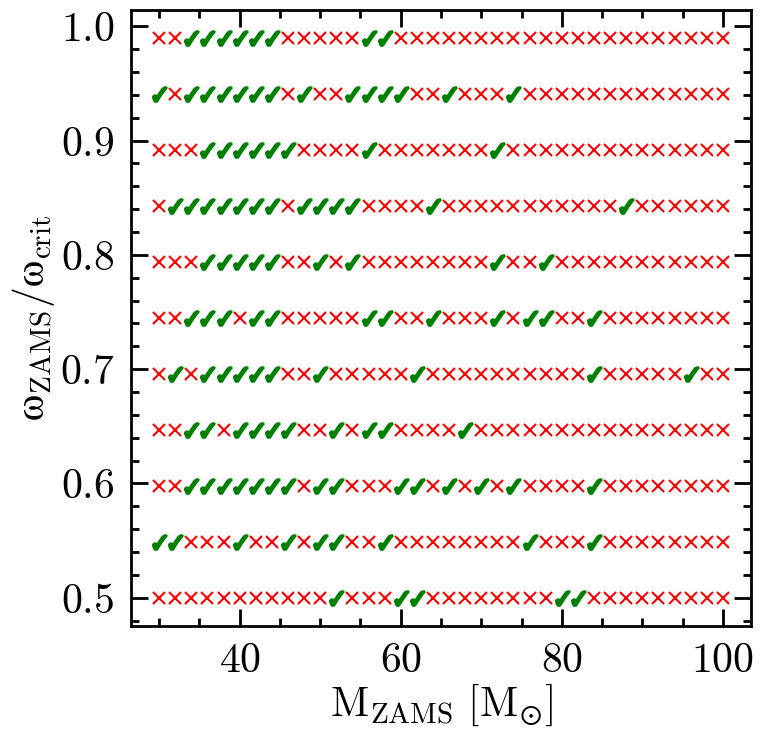

In [14]:
fig = plt.figure()
gs = gridspec.GridSpec(150, 110)
ax = fig.add_subplot(gs[:, :])
omegas = np.linspace(0.5, 0.99, 11)
masses = np.linspace(30, 100, 36)

# Build a set of (M, omega) pairs from existing models
existing = set()
for mod in models:
    M, o = get_model_initial_values(mod)
    existing.add((round(M,2), round(o,2)))

for M in masses:
    for o in omegas:
        if (round(M,2), round(o,2)) in existing:
            ax.plot(M, o, marker='$✓$', color='green', markersize=10, linestyle='None')
        else:
            ax.plot(M, o, marker='x', color='red', markersize=8, linestyle='None',
                    markeredgewidth=1.5)

ax.set_xlabel(r'$M_{\rm ZAMS} \ [M_{\odot}]$')
ax.set_ylabel(r'$\omega_{\rm ZAMS}/\omega_{\rm crit}$')
plt.tight_layout()
# plt.savefig('../manuscript/figures/overview_grid.pdf')

# check max radius

In [7]:
maxR = -1

for mod in models:
    src, col = get_src_col(mod+'LOGS/history.data')
    R = max(10.**(src[:, col.index("log_R")]))
    print(mod, f"{R:.2f}")
    
    if R>= maxR:
        maxR=R

print(f"{maxR:.2f}")

/home/mrenzo/Results/CHE_jets_grid/CLEAN/30.0_rot0.55/ 17.06
/home/mrenzo/Results/CHE_jets_grid/CLEAN/30.0_rot0.94/ 23.78
/home/mrenzo/Results/CHE_jets_grid/CLEAN/32.0_rot0.55/ 14.63
/home/mrenzo/Results/CHE_jets_grid/CLEAN/32.0_rot0.7/ 21.90
/home/mrenzo/Results/CHE_jets_grid/CLEAN/32.0_rot0.84/ 19.99
/home/mrenzo/Results/CHE_jets_grid/CLEAN/34.0_rot0.6/ 25.67
/home/mrenzo/Results/CHE_jets_grid/CLEAN/34.0_rot0.65/ 23.88
/home/mrenzo/Results/CHE_jets_grid/CLEAN/34.0_rot0.74/ 18.65
/home/mrenzo/Results/CHE_jets_grid/CLEAN/34.0_rot0.84/ 19.90
/home/mrenzo/Results/CHE_jets_grid/CLEAN/34.0_rot0.94/ 21.79
/home/mrenzo/Results/CHE_jets_grid/CLEAN/34.0_rot0.99/ 19.40
/home/mrenzo/Results/CHE_jets_grid/CLEAN/36.0_rot0.6/ 23.33
/home/mrenzo/Results/CHE_jets_grid/CLEAN/36.0_rot0.65/ 22.59
/home/mrenzo/Results/CHE_jets_grid/CLEAN/36.0_rot0.7/ 21.23
/home/mrenzo/Results/CHE_jets_grid/CLEAN/36.0_rot0.74/ 20.76
/home/mrenzo/Results/CHE_jets_grid/CLEAN/36.0_rot0.79/ 20.20
/home/mrenzo/Results/CHE_jet

/home/mrenzo/Results/CHE_jets_grid/CLEAN/62.0_rot0.6/ 10.57
/home/mrenzo/Results/CHE_jets_grid/CLEAN/62.0_rot0.7/ 10.57
/home/mrenzo/Results/CHE_jets_grid/CLEAN/64.0_rot0.74/ 10.77
/home/mrenzo/Results/CHE_jets_grid/CLEAN/64.0_rot0.84/ 10.77
/home/mrenzo/Results/CHE_jets_grid/CLEAN/66.0_rot0.6/ 10.94
/home/mrenzo/Results/CHE_jets_grid/CLEAN/66.0_rot0.94/ 10.94
/home/mrenzo/Results/CHE_jets_grid/CLEAN/68.0_rot0.65/ 11.12
/home/mrenzo/Results/CHE_jets_grid/CLEAN/70.0_rot0.6/ 11.30
/home/mrenzo/Results/CHE_jets_grid/CLEAN/72.0_rot0.74/ 11.49
/home/mrenzo/Results/CHE_jets_grid/CLEAN/72.0_rot0.79/ 11.49
/home/mrenzo/Results/CHE_jets_grid/CLEAN/72.0_rot0.89/ 11.49
/home/mrenzo/Results/CHE_jets_grid/CLEAN/74.0_rot0.6/ 11.67
/home/mrenzo/Results/CHE_jets_grid/CLEAN/74.0_rot0.94/ 11.67
/home/mrenzo/Results/CHE_jets_grid/CLEAN/76.0_rot0.55/ 11.86
/home/mrenzo/Results/CHE_jets_grid/CLEAN/76.0_rot0.74/ 11.86
/home/mrenzo/Results/CHE_jets_grid/CLEAN/78.0_rot0.74/ 12.05
/home/mrenzo/Results/CHE_jets